
# 排列组合与概率

## 一、引言：苏记月饼铺的积福盲盒

苏记月饼铺推出积福盲盒，每个盲盒随机装入一枚月饼，共有 6 种口味：A、B、C、D、E、F。集齐全部六种口味，可以兑换一个玉兔福袋。

- 盲盒售价：12 元/个
- 玉兔福袋价值：188 元
- 小明购买：10 个盲盒

以下计算假设六种口味出现的概率相等，且每次抽取相互独立。

### 问题一：购买 10 个月饼有多少种不同选择？

每个盲盒有 6 种口味可选，购买 10 个，允许重复。

根据乘法原理：

$$
N=6^{10}=60,466,176
$$

一般来说，每次有 \(k\) 种选择，连续选择 \(n\) 次，且允许重复时：

$$
N=k^n
$$

这属于可重复排列。

### 问题二：10 个月饼中，6 种口味每一种都至少出现一次，有多少种不同的安排方式？

这是一个容斥原理与第二类斯特林数问题。

#### 方法一：容斥原理（Inclusion-Exclusion）

先计算全部可能的序列，再排除缺少一种或多种口味的情况：

$$
N=\sum_{i=0}^{k}(-1)^i\binom{k}{i}(k-i)^n
$$

代入 \(n=10,k=6\)：

$$
\begin{aligned}
N={}&6^{10}-\binom61 5^{10}
+\binom62 4^{10}\\
&-\binom63 3^{10}
+\binom64 2^{10}
-\binom65 1^{10}
\end{aligned}
$$

$$
\boxed{N=16,435,440}
$$

#### 方法二：第二类斯特林数

第二类斯特林数 \(S(n,k)\) 表示将 \(n\) 个不同元素划分为 \(k\) 个非空、无标号集合的方法数。

先将 10 个位置划分为 6 个非空组，再将 6 个组分配给 6 种不同口味：

$$
N=S(n,k)\cdot k!
$$

本题中：

$$
S(10,6)=22,827
$$

因此：

$$
N=22,827\times6!=16,435,440
$$

### 问题三：小明购买 10 个盲盒，恰好集齐所有口味的概率是多少？这样购买是否划算？

概率定义：

$$
P=\frac{\text{恰好集齐 6 种口味的序列数}}
{\text{购买 10 个盲盒的总序列数}}
$$

总可能序列数：

$$
6^{10}=60,466,176
$$

恰好集齐 6 种口味的序列数：

$$
16,435,440
$$

因此：

$$
P=\frac{16,435,440}{60,466,176}
\approx 0.2718
$$

$$
\boxed{P\approx27.18\%}
$$

购买成本：

$$
C=12\times10=120\text{ 元}
$$

假设未集齐时兑换价值为 0，集齐后获得价值 188 元的福袋，则兑换价值期望为：

$$
\begin{aligned}
E&=188\times P\\
&=188\times27.18\%\\
&\approx51.10\text{ 元}
\end{aligned}
$$

期望净收益：

$$
E_{\text{净}}=51.10-120=-68.90\text{ 元}
$$

因此，在只考虑福袋兑换价值、忽略月饼本身消费价值及其他收益的模型下，这次购买的期望净收益为负。期望是长期平均意义上的数值，不代表小明这一次一定亏损。

### 问题四：平均买多少个盲盒，才能集齐全部六种口味？

这是经典的集齐优惠券问题（Coupon Collector's Problem）。

有 \(k\) 种等概率口味时，集齐全部口味所需抽取次数的期望为：

$$
E_k=kH_k
$$

其中 \(H_k\) 是调和数：

$$
H_k=1+\frac12+\frac13+\cdots+\frac1k
$$

对于六种口味：

$$
H_6=1+\frac12+\frac13+\frac14+\frac15+\frac16
\approx2.45
$$

因此：

$$
E_6=6\times2.45\approx14.7
$$

$$
\boxed{E_6\approx14.7\text{ 个}}
$$

也就是说，平均需要约 15 个盲盒才能集齐六种口味。14.7 是数学期望，并不意味着每次都恰好在第 15 个集齐。

### 问题五：贝叶斯后验推断——开了 20 次盲盒，五仁出现 0 次，小明怀疑老板在五仁月饼上动了手脚？

设五仁月饼的真实出现概率为 \(p\)。先验假设：

$$
p\sim\operatorname{Beta}(1,1)
=\operatorname{Uniform}(0,1)
$$

即在观察数据前，对 \(p\) 使用均匀先验。

观察结果：20 次抽取中，五仁出现 0 次，未出现 20 次。

Beta-Binomial 共轭更新为：

$$
p\mid D\sim\operatorname{Beta}(\alpha+s,\beta+f)
$$

其中 \(s\) 为出现次数，\(f\) 为未出现次数。代入 ($$ \alpha=1,\quad \beta=1,\quad s=0,\quad f=20 $$)：

$$
\boxed{p\mid D\sim\operatorname{Beta}(1,21)}
$$

后验均值为：

$$
E[p\mid D]=\frac{1}{1+21}
=\frac1{22}\approx4.55\%
$$

这表示在当前先验和观测数据下，五仁出现概率的后验均值约为 4.55%。它不能单独证明老板动了手脚；结论还取决于先验假设、抽取是否独立以及口味概率是否相等。

---

## 二、PDD 推荐算法：从随机选择到用户偏好预测

月饼盲盒中，每次口味选择具有随机性；而在推荐系统中，系统需要根据用户历史行为估计其偏好，并从大量商品中筛选和排序。

拼多多（PDD）这类平台的推荐与交易系统并非单一模型，而是由多个算法与业务模块协同组成，例如：

- 推荐与搜索
- 广告
- 定价与补贴
- 拼团机制
- 供应链预测

### 1. 信息流推荐：四层漏斗

工业界常见的信息流推荐流程：

1. **召回**：从海量商品中快速找出候选集。
2. **粗排**：使用计算成本较低的模型进行初步排序。
3. **精排**：使用更复杂的模型预测用户对候选商品的兴趣或行为概率。
4. **重排**：结合多样性、业务规则和展示约束，调整最终结果。

### 2. 矩阵分解

用户与物品的评分矩阵可以近似分解为：

$$
R\approx UV^T
$$

其中：

- \(R\)：用户-物品评分矩阵
- \(U\)：用户隐向量矩阵
- \(V\)：物品隐向量矩阵

**隐向量（Latent Vector）** 是模型从数据中学习到的低维数值表示，用于表达用户或物品的潜在特征。用户向量与物品向量可以通过内积等方式估计偏好。

### 3. 均方误差（MSE）与隐式反馈

对于已有显式评分的数据，可以使用均方误差衡量预测评分与真实评分之间的差异：

$$
MSE=\frac1N\sum_{i=1}^{N}(r_i-\hat r_i)^2
$$

MSE 主要拟合已观测到的评分。对于只有点击、收藏、加购、购买等行为、没有明确评分的数据，需要采用隐式反馈建模方法，不能简单地把未评分等同于负样本。

### 4. BPR：贝叶斯个性化排序

BPR（Bayesian Personalized Ranking）主要用于隐式反馈推荐。

用户没有给商品打分，但可能留下点击、收藏、购买等行为。BPR 学习用户对已交互商品相对于未交互商品的偏好顺序，而不是直接拟合显式评分。

### 5. 双塔模型与向量检索

双塔模型（Two-Tower Model）分别将用户特征和物品特征编码为向量，再通过相似度或内积进行匹配。

$$
score(u,i)=u^Ti
$$

也可以使用余弦相似度：

$$
sim(u,i)=\frac{u\cdot i}{\|u\|\|i\|}
$$

双塔模型常用于大规模候选召回与向量检索。

### 6. 多路召回与合并去重

推荐系统可以通过多种方式生成候选商品，例如协同过滤、双塔向量召回、热门召回、内容召回和图召回。

多路召回结果需要合并、去重，再进入后续排序阶段。

### 7. 轻量 CTR 模型

CTR（Click-Through Rate，点击率）定义为：

$$
CTR=\frac{\text{点击次数}}{\text{曝光次数}}
$$

CTR 预估通常建模为二分类问题，预测用户在给定特征下是否点击：

$$
P(y=1\mid x)
$$

轻量级 DNN 是常见模型形式之一。

### 8. 特征交叉与因子分解机

用户点击行为通常受到多个特征共同影响，例如用户、商品、类别、价格和上下文之间的交互。

因子分解机（FM）使用特征隐向量建模二阶交互，其交互项为：

$$
\sum_{i=1}^{n}\sum_{j=i+1}^{n}
\langle v_i,v_j\rangle x_ix_j
$$

### 9. 概率校准

模型预测的点击概率应尽可能与实际发生频率相匹配。例如，在预测概率接近 20% 的样本群体中，实际点击率也应接近 20%。这就是概率校准的基本含义。

### 10. 同类打散、DPP 与业务约束

重排阶段需要考虑推荐结果的多样性与业务约束，例如：

- 同类商品打散
- 流量约束
- 广告约束
- 品控约束
- 业务规则

DPP（Determinantal Point Process，行列式点过程）可以用于建模候选结果之间的多样性。

---

## 三、概率论与统计学的基础

### 1. 概率论的起源与意义

#### 帕斯卡与费马：概率论的起点

1654 年，帕斯卡与费马围绕赌局中的公平分配问题展开通信，推动了概率论的发展。

概率论逐渐成为研究随机现象与不确定性的数学工具。

#### 伯努利与大数定律

如果抛硬币很多次，正面出现的频率会不会越来越接近 \(1/2\)？

大数定律说明，在适当条件下，随着试验次数增加，样本频率或样本平均值会趋近于理论概率或期望。

#### 贝叶斯与逆概率

贝叶斯思想关注：观察到结果之后，如何更新对原因或未知参数的判断。

贝叶斯定理：

$$
P(A\mid B)=\frac{P(B\mid A)P(A)}{P(B)}
$$

应用包括垃圾邮件过滤、推荐系统、语音识别与 AI 推断。

#### 拉普拉斯与古典概率

拉普拉斯系统发展了古典概率理论。在有限且所有基本结果等可能的情况下：

$$
P(A)=\frac{\text{有利结果数}}{\text{总结果数}}
$$

**概率可以理解为将日常对不确定性的判断转化为可计算的数学描述。**

### 2. 排列组合的源头：计数

排列组合首先解决“有多少种可能”的问题。

例如：

- 10 个人中选出 3 人组成小组：组合。
- 选出队长、副队长和后勤负责人：排列，因为角色不同，顺序或分工有区别。

#### 加法原理

如果完成一件事情有 \(m\) 种互斥方法，另一类有 \(n\) 种方法，选择其中一类完成，则总方法数为：

$$
m+n
$$

#### 乘法原理

如果一件事情分为两个步骤，第一步有 \(m\) 种方法，第二步有 \(n\) 种方法，则总方法数为：

$$
m\times n
$$

#### 排列

从 \(n\) 个不同元素中取出 \(r\) 个，按照顺序排列：

$$
P(n,r)=\frac{n!}{(n-r)!}
$$

#### 组合

从 \(n\) 个不同元素中取出 \(r\) 个，不考虑顺序：

$$
C(n,r)=\frac{n!}{r!(n-r)!}
$$

排列比组合多考虑了所选元素的顺序：

$$
P(n,r)=C(n,r)\cdot r!
$$

### 3. 概率的源头：不确定性

排列组合回答可能性有多少，概率回答某种结果发生的可能性有多大。

概率论的应用包括：

- 随机算法
- 机器学习
- 密码学
- 网络传输
- 推荐系统

排列组合与概率是人类处理可能性和不确定性的基本工具，也是计算机科学、算法分析、数据科学与 AI 中的重要数学基础。

### 4. 古典概率、条件概率与独立事件

古典概率：

$$
P(A)=\frac{\text{有利结果数}}{\text{总结果数}}
$$

条件概率：

$$
P(A\mid B)=\frac{P(A\cap B)}{P(B)},\quad P(B)>0
$$

独立事件：

$$
P(A\cap B)=P(A)P(B)
$$

### 5. 二项分布

二项分布用于描述固定次数、相互独立且每次成功概率相同的伯努利试验中，成功次数的分布。

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

例如抛硬币、广告点击和检测结果等。

### 6. 几何分布

几何分布描述第一次成功所需的试验次数：

$$
P(X=k)=(1-p)^{k-1}p
$$

例如等待第一次中奖、第一次命中或第一次成功。

### 7. 期望与方差

数学期望：

$$
E[X]=\sum_x xP(X=x)
$$

方差：

$$
\operatorname{Var}(X)=E[(X-E[X])^2]
=E[X^2]-(E[X])^2
$$

二项分布的期望与方差：

$$
E[X]=np
$$

$$
\operatorname{Var}(X)=np(1-p)
$$

几何分布的期望与方差：

$$
E[X]=\frac1p
$$

$$
\operatorname{Var}(X)=\frac{1-p}{p^2}
$$

### 8. 贝叶斯定理

$$
P(A\mid B)=\frac{P(B\mid A)P(A)}{P(B)}
$$

- \(P(A)\)：先验概率，观察数据之前的判断。
- **似然（Likelihood）**：P(B | A)，表示在 A 已发生的条件下，观察到 B 的概率。
- **后验概率（Posterior Probability）**：P(A | B)，表示观察到 B 后，对 A 发生概率的更新判断。

### 9. 大数定律

在独立同分布且期望存在等适当条件下：

$$
\frac1n\sum_{i=1}^{n}X_i
\xrightarrow{P}E[X]
$$

直观理解：试验次数足够多时，样本平均值会逐渐趋近总体期望。

### 10. 中心极限定理

在独立同分布、具有有限方差等条件下：

$$
\frac{\sum_{i=1}^{n}X_i-n\mu}{\sigma\sqrt n}
\xrightarrow{d}N(0,1)
$$

其中 \($\mu$) 是总体均值，\($\sigma$) 是总体标准差，\(N(0,1)\) 是标准正态分布。

中心极限定理是统计学的重要基础，解释了为什么正态分布在统计推断中经常出现。





In [14]:
import collections
# 排列组合与概率

import itertools, random
from collections import Counter

import numpy as np

np.random.seed(42)

print('Numpy version', np.__version__)


Numpy version 2.5.3


In [15]:
# 排列:考虑顺序
perms = list(itertools.permutations([1, 2, 3], 2))
print('P(3,2)排列:', perms)
print('数量 = ', len(perms))


P(3,2)排列: [(1, 2), (1, 3), (2, 1), (2, 3), (3, 1), (3, 2)]


In [16]:
# 组合:不考虑顺序
combs = list(itertools.combinations([1, 2, 3], 2))
print('C(3,2) 组合:', combs)
print("数量= ", len(combs), "(=3!/(2!*1!)) =3")

C(3,2) 组合: [(1, 2), (1, 3), (2, 3)]
数量=  3 (=3!/(2!*1!)) =3


In [1]:
# 关系:排列 = 组合 * r!
print(f'验证：P={len(perms)},C×2！=6')

NameError: name 'perms' is not defined

In [17]:
def factorial(n):
    r = 1
    for i in range(1, n + 1):
        r *= i
    return r


def P(n, r):
    r2 = 1
    for i in range(r):
        r2 *= (n - i)
    return r2


def C(n, r):
    return P(n, r) // factorial(r)


print('P(10,3) =', P(10, 3))
print('C(10,3) =', C(10, 3))
print('C(52,5) =', C(52, 5))


P(10,3) = 720
C(10,3) = 120
C(52,5) = 120


In [18]:
#  大数定律

random.seed(0)

rations = []
heads = 0

for n in range(1, 100001):
    if random.random() < 0.5:
        heads += 1
    rations.append(heads / n)
print(f"抛10次:正面比例= {rations[9]:.3f}")
print(f"抛100次:正面比例= {rations[99]:.3f}")
print(f"抛1000次:正面比例= {rations[999]:.3f}")
print(f"抛10000次:正面比例= {rations[9999]:.3f}")
print()
print("观察:抛得越多,越接近 0.5")

抛10次:正面比例= 0.500
抛100次:正面比例= 0.370
抛1000次:正面比例= 0.508
抛10000次:正面比例= 0.498

观察:抛得越多,越接近 0.5


In [22]:
# 作业1: 扑克牌的概率
import random

# 扑克牌
suits = ['♠', '♥', '♦', '♣']
ranks = ['A', '2', '3', '4', '5', '6', '7',
         '8', '9', '10', 'J', 'Q', 'K']
cards = [(s, r) for r in ranks for s in suits]

# 模拟次数
nums = 10000

count_heart = 0
count_ace = 0
count_red = 0
count_face = 0
count_red_face = 0

for _ in range(nums):
    suit, rank = random.choice(cards)

    # 1. 红桃
    if suit == '♥':
        count_heart += 1

    # 2. A
    if rank == 'A':
        count_ace += 1

    # 3. 红色牌
    if suit in ['♥', '♦']:
        count_red += 1

    # 4. 人头牌 J、Q、K
    if rank in ['J', 'Q', 'K']:
        count_face += 1

    # 5. 红色人头牌
    if suit in ['♥', '♦'] and rank in ['J', 'Q', 'K']:
        count_red_face += 1

print("红桃概率：", count_heart / nums)
print("A 概率：", count_ace / nums)
print("红色牌概率：", count_red / nums)
print("人头牌概率：", count_face / nums)
print("红色人头牌概率：", count_red_face / nums)



红桃概率： 0.2476
A 概率： 0.0782
红色牌概率： 0.5002
人头牌概率： 0.2346
红色人头牌概率： 0.1188


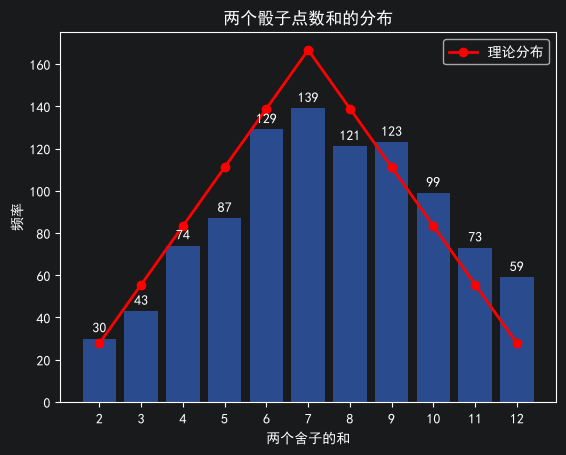

In [21]:
# 作业2: 挣色子,两个色子和的分布
import random
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

nums = 1000
cnt = Counter()
res = []
for _ in range(nums):
    num1 = random.randint(1, 6)
    num2 = random.randint(1, 7)
    sum_ = num1 + num2
    cnt[sum_] += 1

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 可视化分布
x = np.arange(2, 13)
y = np.array([cnt[i] for i in x])
bar = plt.bar(x, y, alpha=0.6)
plt.bar_label(bar, padding=3)

theory_count = np.array([
    1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1
]) / 36 * nums

# 绘制理论曲线
plt.plot(
    x,
    theory_count,
    'r-o',
    linewidth=2,
    label='理论分布'
)

plt.xlabel('两个舍子的和')
plt.ylabel('频率')
plt.title("两个骰子点数和的分布")
plt.xticks(x)
plt.legend()
plt.show()
